In [1]:
pip install numpy

  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl (5.2 MB)

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
import matplotlib.pyplot as plt

In [3]:
import src.models as models

ModuleNotFoundError: No module named 'src'

In [2]:
import sys
import os
import importlib.util

# 1. Define the path to the models file
# Assuming you are in the 'notebooks' folder or similar, we go up one level to 'src'
path_to_models = os.path.abspath(os.path.join('..', 'src', 'models.py'))

# 2. Load the module specifically
spec = importlib.util.spec_from_file_location("models_direct", path_to_models)
models_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(models_module)

# 3. Pull the functions you need
build_model = models_module.build_model
GATv2_Model = models_module.GATv2_Model

print("✅ Success! Models loaded by bypassing src/__init__.py")

/Users/allenjamesvinoy/Downloads/DLProject/gat-wrecked/.venv2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Success! Models loaded by bypassing src/__init__.py


In [3]:
# 1. Generate the Dictionary Data (50 nodes, 2D Q/K/V)
def get_data(n=50):
    q, k, v = torch.randn(n, 2), torch.randn(n, 2), torch.randn(n, 2)
    x = torch.cat([q, k, v], dim=1) 
    adj = torch.ones(n, n) # Fully connected
    labels = torch.tensor([torch.argmin(torch.norm(k - q[i], dim=1)) for i in range(n)])
    return x, adj, labels

x, adj, labels = get_data()

In [4]:
# 1. Initialize the standard GAT model
# We use the same hyperparameters (32 hidden, 4 heads) for a fair comparison
model_gat = build_model("gat", nfeat=6, nhid=32, nclass=50, nheads=4, dropout=0.1, alpha=0.2)
optimizer_gat = torch.optim.Adam(model_gat.parameters(), lr=0.01)

print(f"{'Epoch':<8} | {'Loss':<8} | {'Acc':<8} ")
print("-" * 40)

for epoch in range(1001):
    model_gat.train()
    optimizer_gat.zero_grad()
    
    # Forward pass
    out = model_gat(x, adj)
    loss = F.nll_loss(out, labels)
    
    # Backward pass
    loss.backward()
    optimizer_gat.step()
    
    if epoch % 100 == 0:
        model_gat.eval()
        with torch.no_grad():
            pred = model_gat(x, adj)
            acc = (pred.argmax(1) == labels).float().mean().item()
            print(f"{epoch:<8} | {loss.item():<8.4f} | {acc:<8.2%}")

print("-" * 50)
print(f"GAT Final Accuracy: {acc:.2%}")

Epoch    | Loss     | Acc      
----------------------------------------
0        | 3.9998   | 6.00%   
100      | 3.4462   | 10.00%  
200      | 3.4383   | 10.00%  
300      | 3.4409   | 10.00%  
400      | 3.4392   | 10.00%  
500      | 3.4394   | 10.00%  
600      | 3.4410   | 10.00%  
700      | 3.4398   | 10.00%  
800      | 3.4436   | 10.00%  
900      | 3.4356   | 10.00%  
1000     | 3.4393   | 10.00%  
--------------------------------------------------
GAT Final Accuracy: 10.00%


In [5]:
import numpy as np

# Re-initialize for a fresh tracked run
model_v2 = GATv2_Model(nfeat=6, nhid=32, nclass=50, nheads=4, dropout=0.1, alpha=0.2)
optimizer = torch.optim.Adam(model_v2.parameters(), lr=0.01)

print(f"{'Epoch':<8} | {'Loss':<8} | {'Acc':<8}")
print("-" * 40)

for epoch in range(1501):
    model_v2.train()
    optimizer.zero_grad()
    
    out = model_v2(x, adj)
    loss = F.nll_loss(out, labels)
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0 or epoch == 1500:
        model_v2.eval()
        with torch.no_grad():
            # Get the output and calculate metrics
            current_out = model_v2(x, adj)
            acc = (current_out.argmax(1) == labels).float().mean().item()
            print(f"{epoch:<8} | {loss.item():<8.4f} | {acc:<8.2%} |")

        if acc >= 1.0:
            print("-" * 60)
            print(f"100% Accuracy reached at epoch {epoch}!")
            break

Epoch    | Loss     | Acc     
----------------------------------------
0        | 4.0661   | 6.00%    |
100      | 2.3836   | 40.00%   |
200      | 1.7175   | 56.00%   |
300      | 1.3201   | 80.00%   |
400      | 1.0878   | 94.00%   |
500      | 1.3831   | 96.00%   |
600      | 0.8761   | 88.00%   |
700      | 0.5905   | 96.00%   |
800      | 0.5292   | 96.00%   |
900      | 0.6382   | 96.00%   |
1000     | 0.6159   | 100.00%  |
------------------------------------------------------------
100% Accuracy reached at epoch 1000!


## Figure-1-style attention visualization (current run)

This plots first-layer attention for the first 10 query/key indices (`q0..q9`, `k0..k9`) so we can directly compare:

- **GAT**: expected to show mostly query-independent ranking (static attention)
- **GATv2**: expected to show query-dependent rankings (dynamic attention)

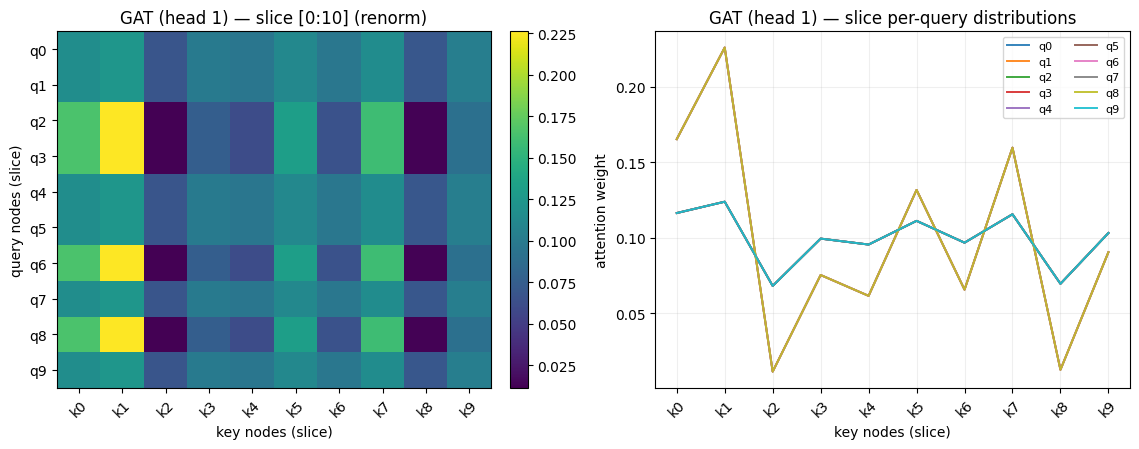

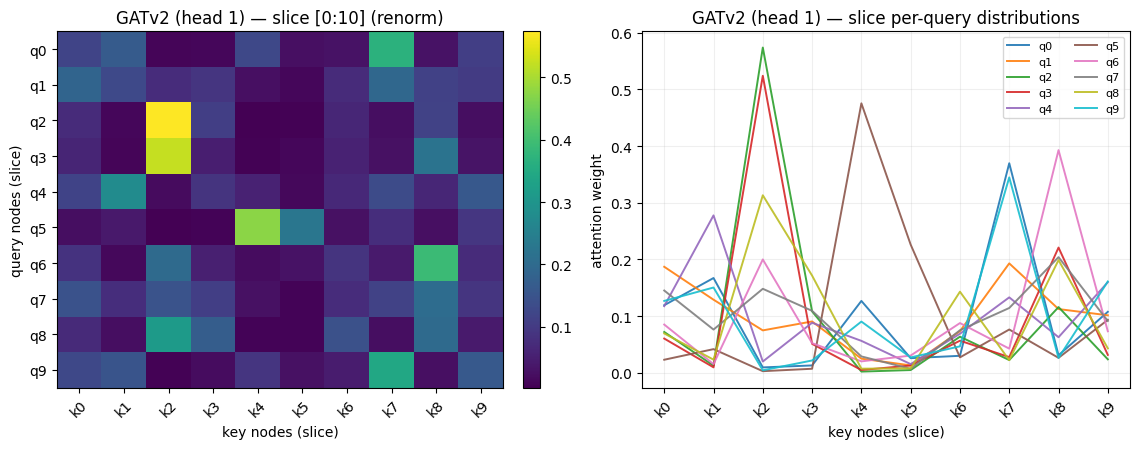

In [100]:
import matplotlib.pyplot as plt


def select_head_or_average(head_stack, head_idx=None):
    """
    head_stack: Tensor [H, N, N]
    head_idx: None -> average over heads, int -> specific head
    """
    if head_idx is None:
        return head_stack.mean(dim=0)
    if not (0 <= head_idx < head_stack.size(0)):
        raise ValueError(f"head_idx must be in [0, {head_stack.size(0) - 1}]")
    return head_stack[head_idx]


def extract_gat_attention_first_layer(model, x, adj):
    model.eval()
    with torch.no_grad():
        _, head_attn = model(x, adj, return_attn=True)
        # list of [N, N], one per head -> [H, N, N]
        return torch.stack(head_attn, dim=0)


def extract_gatv2_attention_first_layer(model, x, adj):
    """Reconstruct first-layer attention weights from trained GATv2 heads."""
    model.eval()
    with torch.no_grad():
        x_in = F.dropout(x, model.dropout, training=False)
        n = x_in.size(0)
        all_heads = []

        for layer in model.attentions:
            h_i = x_in.repeat_interleave(n, dim=0)
            h_j = x_in.repeat(n, 1)

            e = layer.leakyrelu(layer.W(torch.cat([h_i, h_j], dim=1)))
            e = torch.matmul(e, layer.a).squeeze(1).view(n, n)

            zero_vec = torch.full_like(e, -1e9)
            e = torch.where(adj > 0, e, zero_vec)
            alpha = F.softmax(e, dim=1)
            all_heads.append(alpha)

        # [H, N, N]
        return torch.stack(all_heads, dim=0)


def slice_for_display(attn, start=0, size=20, renorm=True):
    """Take a display slice from attn; optional row renormalization for readability."""
    end = min(start + size, attn.size(0))
    block = attn[start:end, start:end]
    if renorm:
        block = block / block.sum(dim=1, keepdim=True).clamp_min(1e-12)
    return block


def plot_attention_panels(attn, title, slice_start=0, slice_size=10, renorm_slice=True):
    """Show only slice matrix + slice per-query distributions."""
    attn_slice = slice_for_display(attn, start=slice_start, size=slice_size, renorm=renorm_slice)
    a_slice = attn_slice.detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

    # Slice matrix
    m = a_slice.shape[0]
    im1 = axes[0].imshow(a_slice, aspect='auto', interpolation='nearest')
    mode = "renorm" if renorm_slice else "raw"
    axes[0].set_title(f"{title} — slice [{slice_start}:{slice_start + m}] ({mode})")
    axes[0].set_xlabel("key nodes (slice)")
    axes[0].set_ylabel("query nodes (slice)")
    axes[0].set_xticks(range(m))
    axes[0].set_xticklabels([f"k{slice_start + i}" for i in range(m)], rotation=45)
    axes[0].set_yticks(range(m))
    axes[0].set_yticklabels([f"q{slice_start + i}" for i in range(m)])
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Slice per-query distributions
    for i in range(m):
        axes[1].plot(range(m), a_slice[i], linewidth=1.4, alpha=0.9, label=f"q{slice_start + i}")
    axes[1].set_title(f"{title} — slice per-query distributions")
    axes[1].set_xlabel("key nodes (slice)")
    axes[1].set_ylabel("attention weight")
    axes[1].set_xticks(range(m))
    axes[1].set_xticklabels([f"k{slice_start + i}" for i in range(m)], rotation=45)
    axes[1].grid(alpha=0.2)
    axes[1].legend(ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()


# ---- Controls ----
# Set to None for head-averaged attention; set to an integer (e.g., 0) for a single head.
head_idx = 1

# Slice controls for simpler paper-like view from this same experiment
slice_start = 0
slice_size = 10
renorm_slice = True  # visualization-only normalization within the displayed slice

# Compute first-layer head stacks
gat_heads = extract_gat_attention_first_layer(model_gat, x, adj)
gatv2_heads = extract_gatv2_attention_first_layer(model_v2, x, adj)

# Select one head or average
attn_gat = select_head_or_average(gat_heads, head_idx=head_idx)
attn_gatv2 = select_head_or_average(gatv2_heads, head_idx=head_idx)

head_label = "avg heads" if head_idx is None else f"head {head_idx}"
plot_attention_panels(
    attn_gat,
    f"GAT ({head_label})",
    slice_start=slice_start,
    slice_size=slice_size,
    renorm_slice=renorm_slice,
)
plot_attention_panels(
    attn_gatv2,
    f"GATv2 ({head_label})",
    slice_start=slice_start,
    slice_size=slice_size,
    renorm_slice=renorm_slice,
)

## Figure 3 Replication: DICTIONARYLOOKUP Benchmark

Tests whether models can match query nodes to correct key nodes in a bipartite graph.

- **X-axis:** k (problem size, 4–20)
- **Y-axis:** Accuracy (0–100%)

### Expected Results

| Model | Behaviour |
|---|---|
| GAT 1h train/test | Near 0% — fails to fit even training data |
| GAT 8h test | Fits training but generalises poorly |
| GATv2 1h test | Flat 100% across all k |

**Takeaway:** GATv2's dynamic attention solves the task perfectly with a single head; standard GAT fails regardless of head count.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


In [ ]:
class GATLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout, alpha, concat=True, gain=1.414):
        super(GATLayer, self).__init__()
        self.dropout = dropout
        self.in_features = in_features
        self.out_features = out_features
        self.alpha = alpha
        self.concat = concat

        self.W = nn.Parameter(torch.empty(size=(in_features, out_features)))
        nn.init.xavier_uniform_(self.W.data, gain=gain)

        self.a = nn.Parameter(torch.empty(size=(2 * out_features, 1)))
        nn.init.xavier_uniform_(self.a.data, gain=gain)

        self.leakyrelu = nn.LeakyReLU(self.alpha)

    def forward(self, h, adj, return_attn=False):
        Wh = torch.mm(h, self.W)
        N = Wh.size()[0]

        a_input = torch.cat([Wh.repeat_interleave(N, dim=0), Wh.repeat(N, 1)], dim=1)
        a_input = a_input.view(N, N, 2 * self.out_features)
        e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))

        zero_vec = -1e9 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, Wh)

        out = F.elu(h_prime) if self.concat else h_prime
        if return_attn:
            return out, attention
        return out


class GATv2Layer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.2, alpha=0.2, concat=True):
        super(GATv2Layer, self).__init__()
        self.dropout = dropout
        self.concat = concat

        self.W      = nn.Linear(2 * in_features, out_features, bias=True)
        self.W_prop = nn.Linear(in_features, out_features, bias=False)
        self.a      = nn.Parameter(torch.empty(size=(out_features, 1)))

        nn.init.xavier_uniform_(self.W.weight, gain=1.414)
        nn.init.xavier_uniform_(self.W_prop.weight, gain=1.414)
        nn.init.xavier_uniform_(self.a.data, gain=1.414)
        self.leakyrelu = nn.LeakyReLU(alpha)

    def forward(self, h, adj):
        N = h.size()[0]
        h_i = h.repeat_interleave(N, dim=0)
        h_j = h.repeat(N, 1)

        e = self.leakyrelu(self.W(torch.cat([h_i, h_j], dim=1)))
        e = torch.matmul(e, self.a).squeeze(1).view(N, N)

        zero_vec = -1e9 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)

        Wh = self.W_prop(h)
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime) if self.concat else h_prime

class SingleLayerGAT(nn.Module):
    """One attention layer + linear classifier. Matches the paper's single-layer setup."""
    def __init__(self, nfeat, nhid, nclass, dropout, alpha, nheads):
        super().__init__()
        self.dropout = dropout
        self.heads = nn.ModuleList([
            GATLayer(nfeat, nhid, dropout=dropout, alpha=alpha, concat=True)
            for _ in range(nheads)
        ])
        self.clf = nn.Linear(nhid * nheads, nclass)

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, training=self.training)
        x = torch.cat([h(x, adj) for h in self.heads], dim=1)
        return F.log_softmax(self.clf(x), dim=1)


class SingleLayerGATv2(nn.Module):
    def __init__(self, nfeat, nhid, nclass, dropout, alpha, nheads):
        super().__init__()
        self.dropout = dropout
        self.heads = nn.ModuleList([
            GATv2Layer(nfeat, nhid, dropout=dropout, alpha=alpha, concat=True)
            for _ in range(nheads)
        ])
        self.clf = nn.Linear(nhid * nheads, nclass)

    def forward(self, x, adj):
        x = F.dropout(x, self.dropout, training=self.training)
        x = torch.cat([h(x, adj) for h in self.heads], dim=1)
        return F.log_softmax(self.clf(x), dim=1)


def get_discrete_data(k, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    n = 2 * k

    perm = torch.randperm(k)

    q_attr = torch.eye(k)

    k_attr = torch.eye(k)
    k_val  = torch.eye(k)[perm]

    q_feat = torch.cat([q_attr, torch.zeros(k, k)], dim=1)
    k_feat = torch.cat([k_attr, k_val],             dim=1)

    x   = torch.cat([q_feat, k_feat], dim=0)
    adj = torch.ones(n, n)

    labels = torch.cat([
        perm + k,
        torch.arange(k, 2 * k)
    ])
    return x, adj, labels


def get_dataset(k, n_graphs=200, seed_offset=0):
    """Returns a list of (x, adj, labels) with different random mappings."""
    return [get_discrete_data(k, seed=seed_offset + i) for i in range(n_graphs)]


def train_and_eval(model, train_set, test_set, epochs=200, lr=0.005):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    for _ in range(epochs):
        model.train()
        for x, adj, y in train_set:
            x, adj, y = x.to(device), adj.to(device), y.to(device)
            opt.zero_grad()
            k = len(train_set[0][2]) // 2
            out = model(x, adj)
            F.nll_loss(out[:k], y[:k]).backward()
            opt.step()

    def accuracy(dataset):
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, adj, y in dataset:
                x, adj, y = x.to(device), adj.to(device), y.to(device)
                k = len(y) // 2
                pred = model(x, adj).argmax(1)[:k]
                correct += (pred == y[:k]).sum().item()
                total   += k
        return correct / total * 100

    return accuracy(train_set), accuracy(test_set)

k_values = list(range(4, 21))
res = {'gatv2_te': [], 'gat8h_te': [], 'gat1h_tr': [], 'gat1h_te': []}

for k in k_values:
    nfeat = 2 * k
    nclass = 2 * k
    nhid = 64

    train_set = get_dataset(k, n_graphs=100, seed_offset=0)
    test_set = get_dataset(k, n_graphs=50, seed_offset=9999)
    print(f"k={k:2d}", end="  ", flush=True)

    m = SingleLayerGAT(nfeat, nhid, nclass, dropout=0.1, alpha=0.2, nheads=1)
    tr, te = train_and_eval(m, train_set, test_set)
    res['gat1h_tr'].append(tr);  res['gat1h_te'].append(te)
    print(f"GAT_1h  train={tr:.0f}% test={te:.0f}%", end="  ", flush=True)

    m = SingleLayerGAT(nfeat, nhid, nclass, dropout=0.1, alpha=0.2, nheads=8)
    _, te = train_and_eval(m, train_set, test_set)
    res['gat8h_te'].append(te)
    print(f"GAT_8h  test={te:.0f}%", end="  ", flush=True)

    m = SingleLayerGATv2(nfeat, nhid, nclass, dropout=0.1, alpha=0.2, nheads=1)
    _, te = train_and_eval(m, train_set, test_set)
    res['gatv2_te'].append(te)
    print(f"GATv2   test={te:.0f}%")



Saved: dictionary_lookup_chart_v2.png


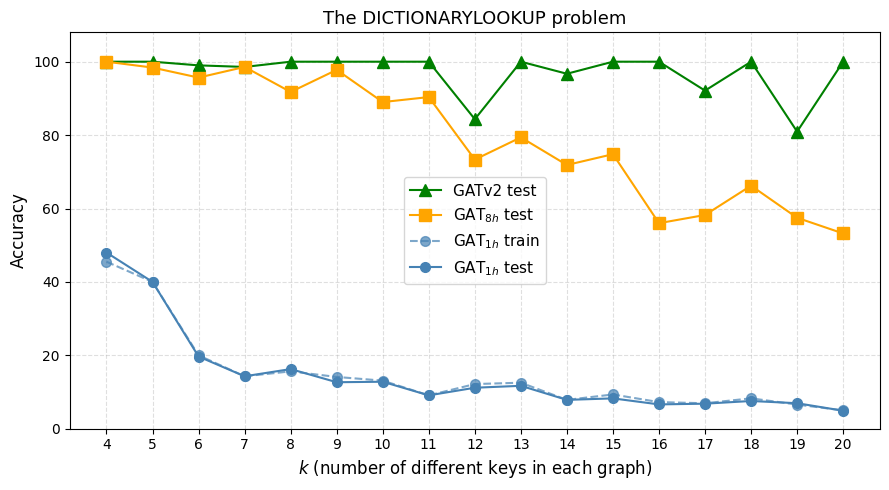

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, res['gatv2_te'],  'g^-',  label='GATv2 test',       markersize=9)
ax.plot(k_values, res['gat8h_te'],  's-',   label='GAT$_{8h}$ test',  markersize=8, color='orange')
ax.plot(k_values, res['gat1h_tr'],  'o--',  label='GAT$_{1h}$ train', markersize=7, color='steelblue', alpha=0.7)
ax.plot(k_values, res['gat1h_te'],  'o-',   label='GAT$_{1h}$ test',  markersize=7, color='steelblue')
ax.set_xlabel('$k$ (number of different keys in each graph)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('The DICTIONARYLOOKUP problem', fontsize=13)
ax.set_xticks(k_values)
ax.set_ylim(0, 108)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('dictionary_lookup_chart_v2.png', dpi=150)
print("\nSaved: dictionary_lookup_chart_v2.png")